# The dataset for this problem is an example dataset in the sklearn package. Import the dataset by writing the following statements at the beginning of your code

In [1]:
from sklearn import datasets
import pandas as pd
data = datasets.load_breast_cancer()
X = data.data
y = data.target

In [2]:
import warnings
warnings.filterwarnings('ignore')

## NOTE : As this data has more than 2 features it might be difficult to draw decision boundaries. Plotting decision boundaries is not mandatory for this assignment.   

## 1. Data Exploration and Preprocessing:

    Load the Breast Cancer dataset from scikit-learn.
    Perform a basic exploration of the dataset. What are the features? What are the target classes?
    Split the data into training and testing sets.

In [3]:
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

## 2. Data Visualization:

    Visualize the distribution of target classes.
    Plot some of the features to understand the relationships between them. Consider using scatter plots, histograms, etc.

In [4]:
#Checking the shape of the data
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (569, 30)
Shape of y: (569,)


In [5]:
#Checking the first few rows of the data
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

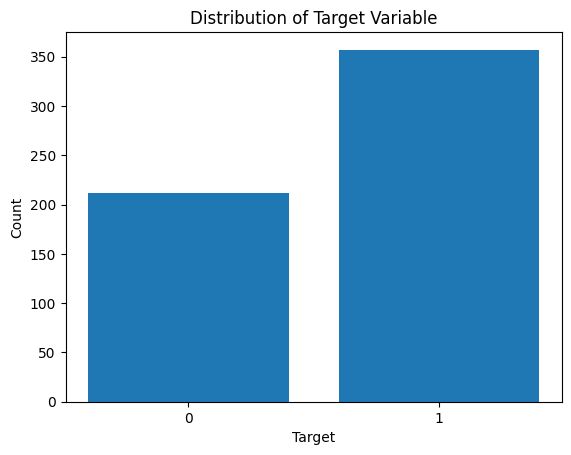

In [6]:
#Target Distribution
import matplotlib.pyplot as plt
import seaborn as sns
plt.hist(y, bins=[-0.5, 0.5, 1.5], rwidth=0.8, align='mid')
plt.xticks([0, 1])
plt.title('Distribution of Target Variable')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()



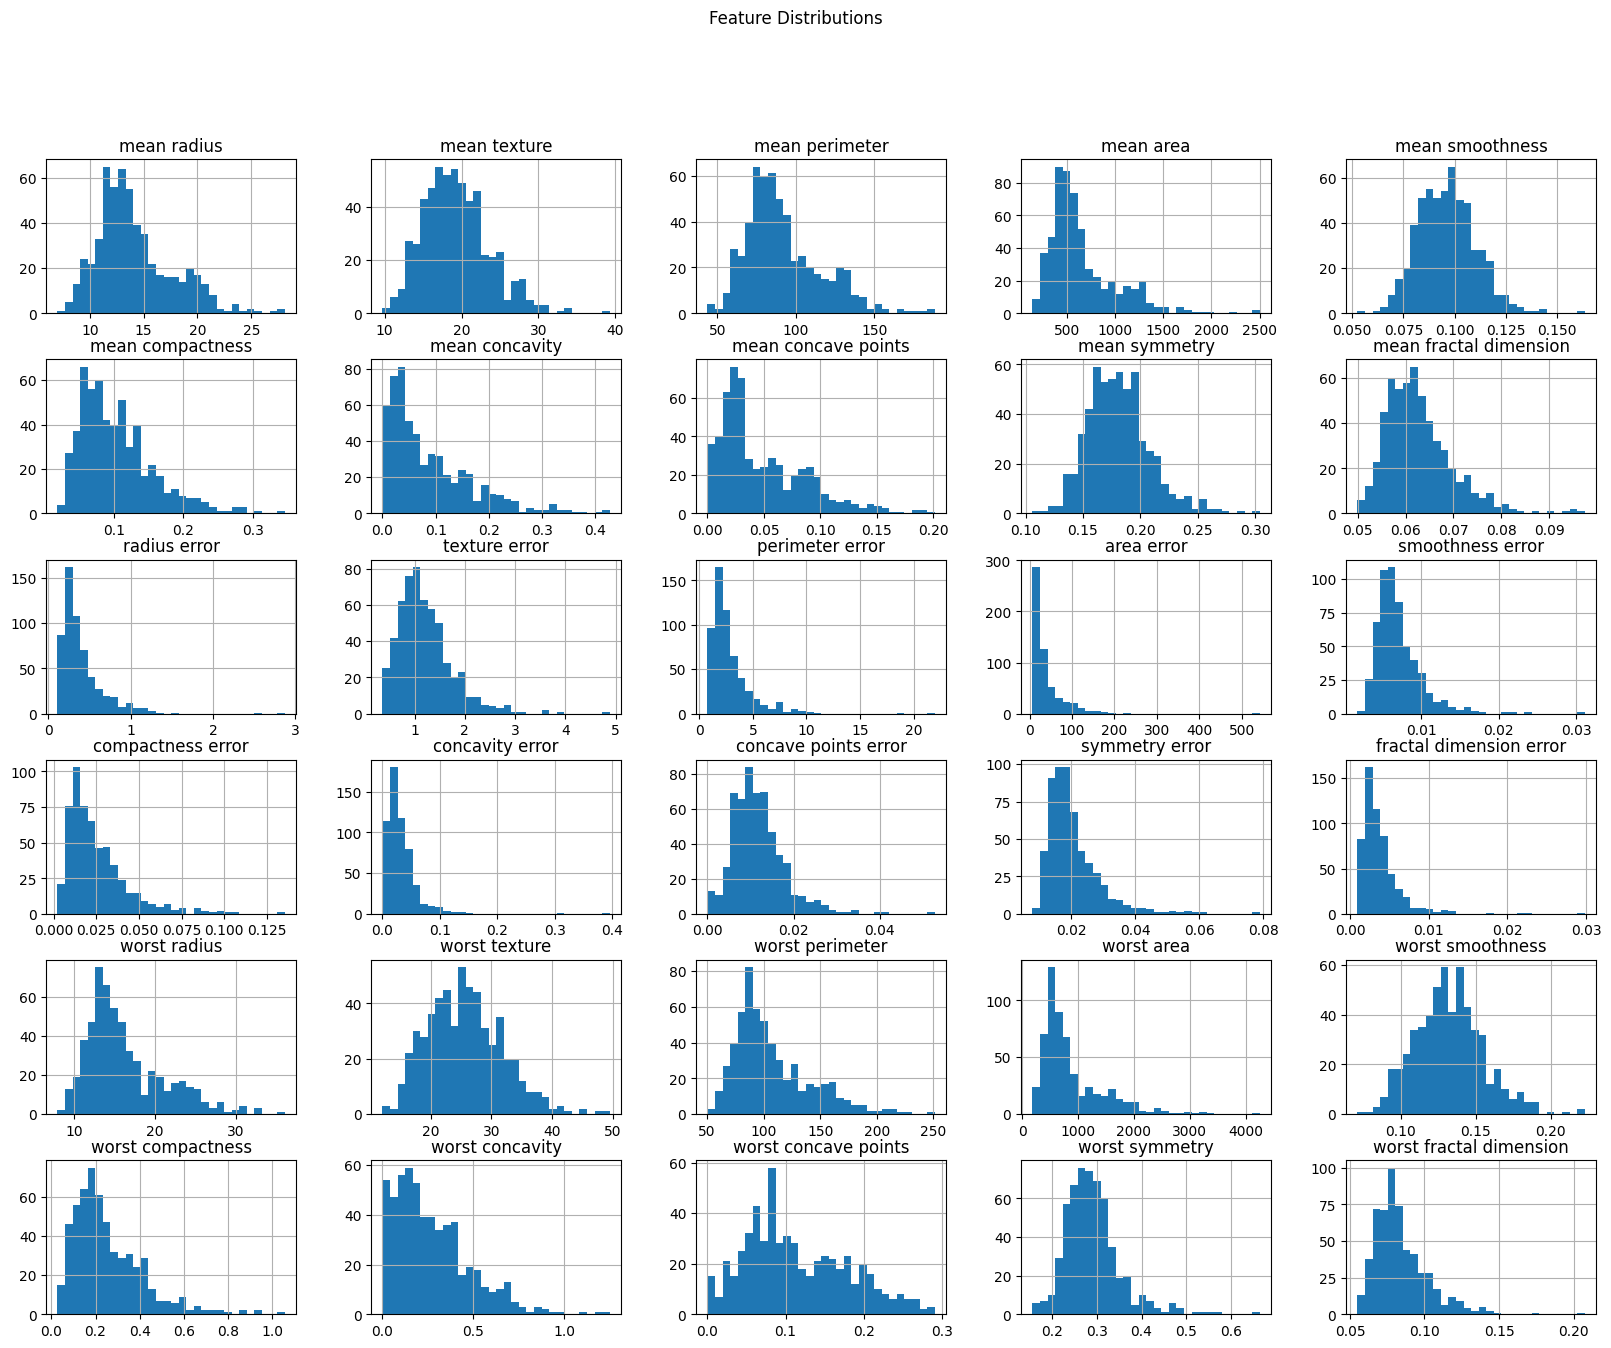

In [7]:
#Visualize the distribution of each feature
df.drop('target', axis=1).hist(bins=30, figsize=(20, 15))
plt.suptitle('Feature Distributions')
plt.show()

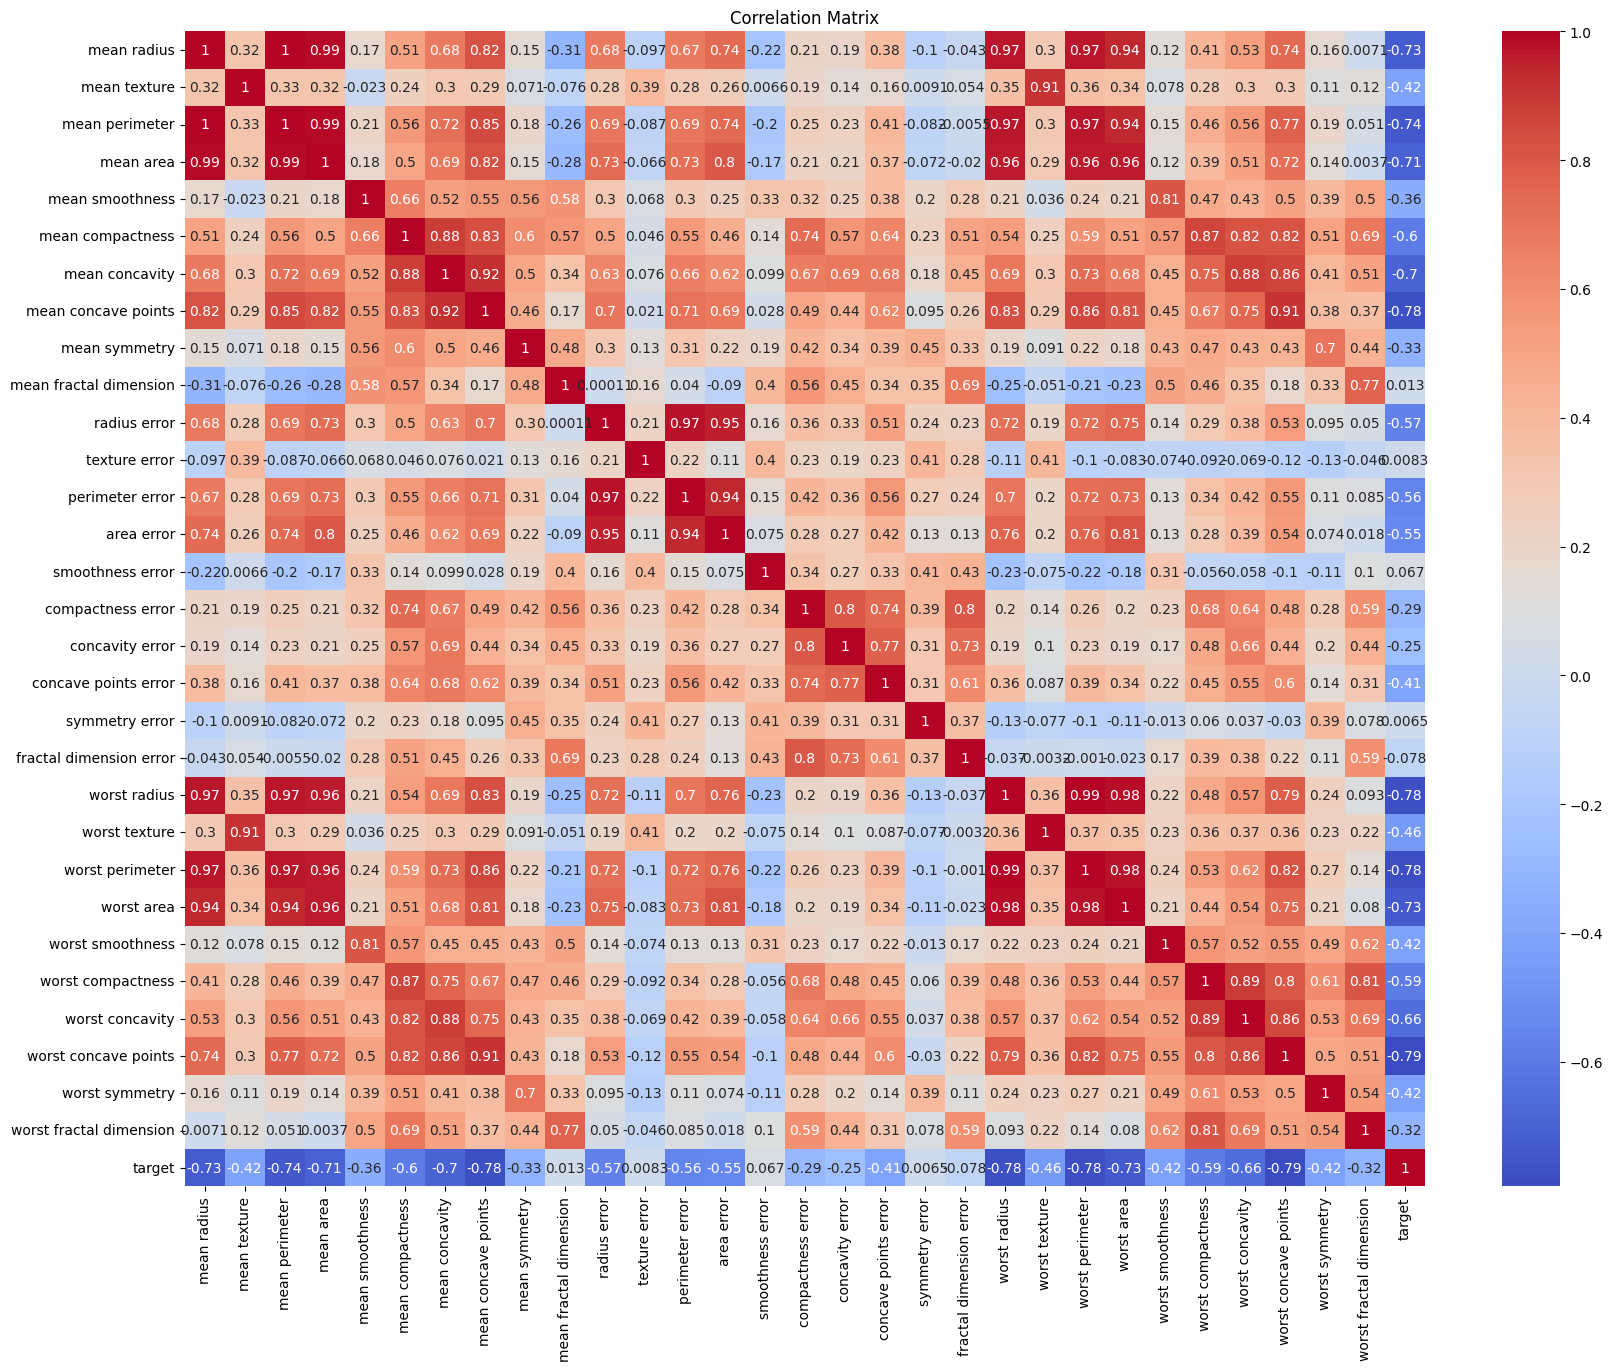

In [8]:
#Correlation Matrix
import seaborn as sns
correlation_matrix = df.corr()
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

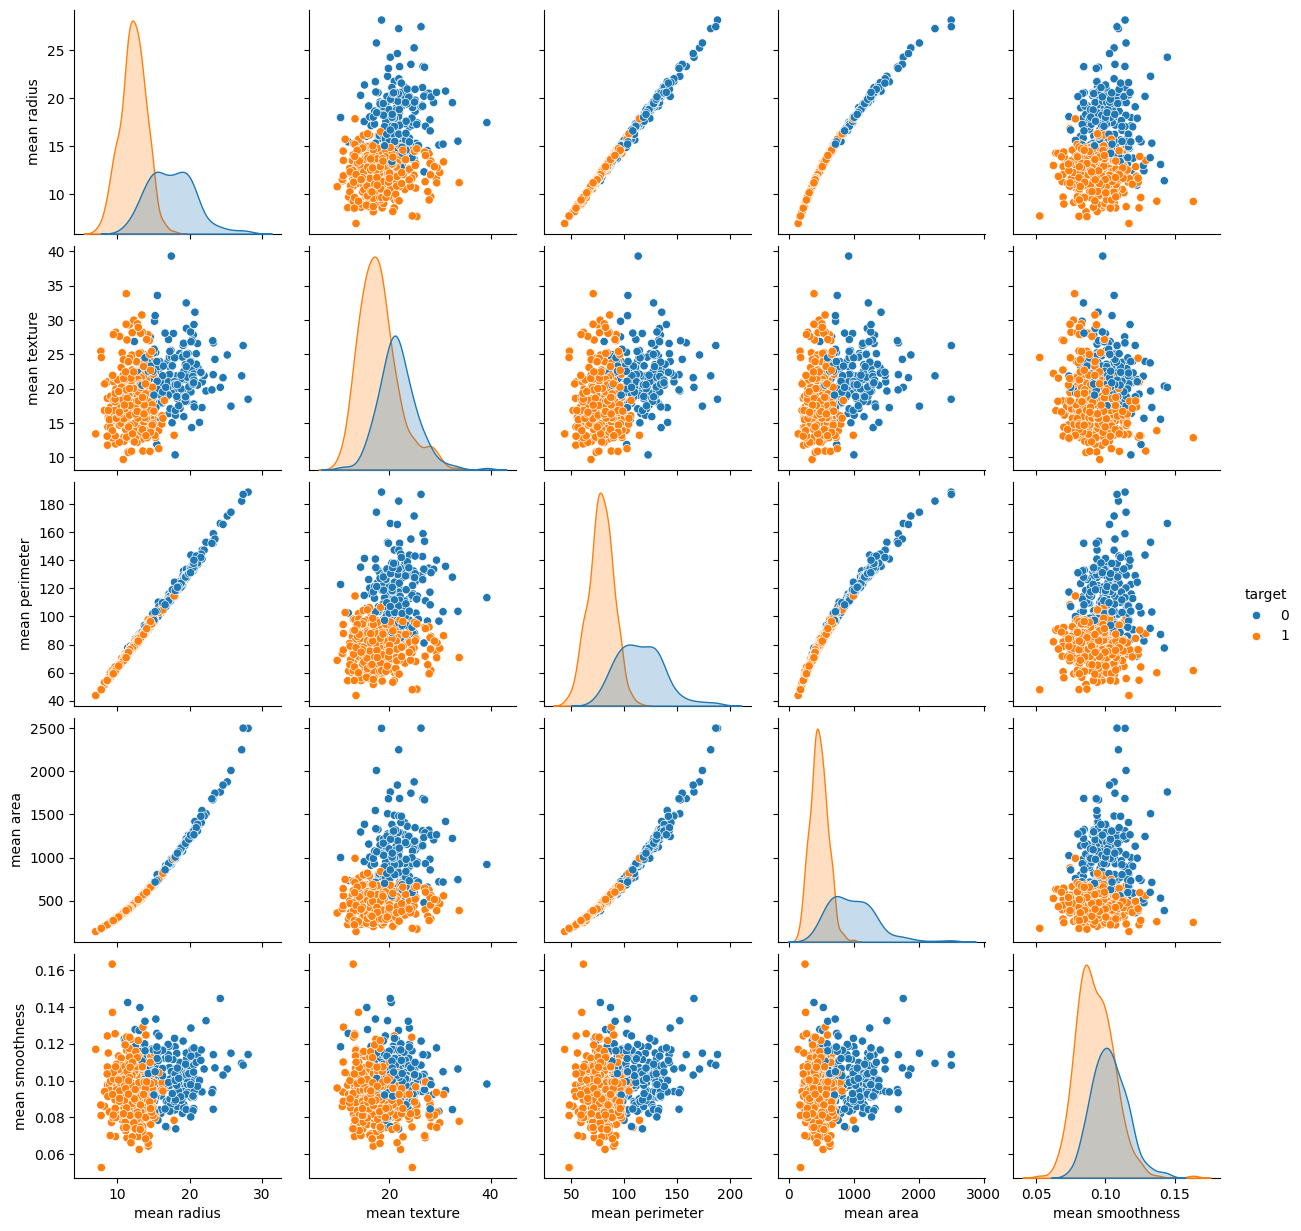

In [9]:
#Pairplots for selected features
selected_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']
sns.pairplot(df, vars=selected_features, hue='target')
plt.show()

## 3. Model Training and Evaluation:

    Train at least three different classifiers and find best hyperparameters, such as Logistic Regression, Decision       Tree, and Support Vector Machine.
    Evaluate the models using appropriate metrics like accuracy and ROC curve, etc.
    Draw Confusion Matrix for the best Model and calculate Precision, Recall, F1 Score!
    Compare the models and show the findings.

In [10]:
# Spilitting the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
#LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

grid_search_lr = GridSearchCV(LogisticRegression(solver='liblinear'), param_grid_lr, cv=5)
grid_search_lr.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=LogisticRegression(solver='liblinear'),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'penalty': ['l1', 'l2']})

In [12]:
#DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier

param_grid_dt = {
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_dt = GridSearchCV(DecisionTreeClassifier(), param_grid_dt, cv=5)
grid_search_dt.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [None, 10, 20, 30, 40, 50],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]})

In [13]:
#SVM
from sklearn.svm import SVC

param_grid_svc = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear']
}

grid_search_svc = GridSearchCV(SVC(probability=True), param_grid_svc, cv=2)
grid_search_svc.fit(X_train, y_train)


GridSearchCV(cv=2, estimator=SVC(probability=True),
             param_grid={'C': [0.1, 1, 10, 100], 'kernel': ['rbf', 'linear']})

In [14]:
# Model Evaluation
print("Logistic Regression Accuracy:", grid_search_lr.score(X_test, y_test))
print("Decision Tree Accuracy:", grid_search_dt.score(X_test, y_test))
print("SVM Accuracy:", grid_search_svc.score(X_test, y_test))

Logistic Regression Accuracy: 0.9824561403508771
Decision Tree Accuracy: 0.9385964912280702
SVM Accuracy: 0.956140350877193


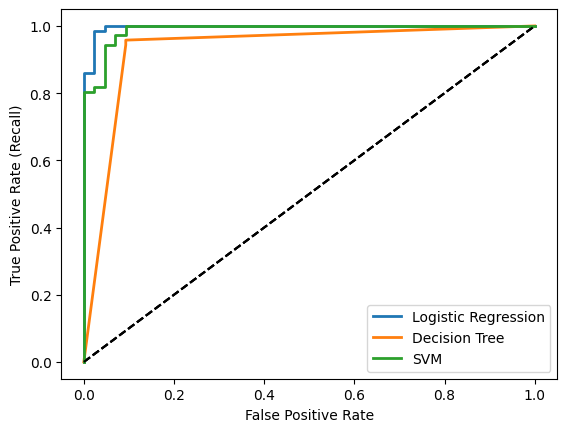

In [15]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_curve(model, X, y, label=None):
    probs = model.predict_proba(X)[:, 1]
    fpr, tpr, thresholds = roc_curve(y, probs)
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate (Recall)')

plot_roc_curve(grid_search_lr, X_test, y_test, "Logistic Regression")
plot_roc_curve(grid_search_dt, X_test, y_test, "Decision Tree")
plot_roc_curve(grid_search_svc, X_test, y_test, "SVM")
plt.legend()
plt.show()


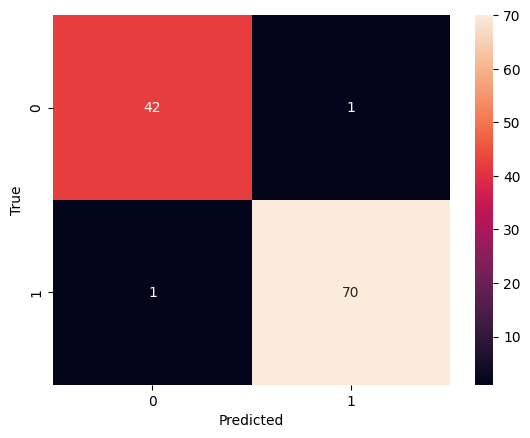

Precision: 0.9859154929577465
Recall: 0.9859154929577465
F1 Score: 0.9859154929577465


In [16]:
#Confusion Matrics
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

y_pred = grid_search_lr.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Precision, Recall, F1 Score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


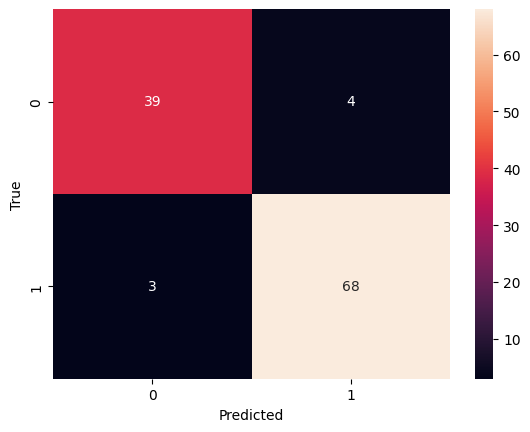

Precision: 0.9444444444444444
Recall: 0.9577464788732394
F1 Score: 0.951048951048951


In [17]:
y_pred = grid_search_dt.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Precision, Recall, F1 Score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

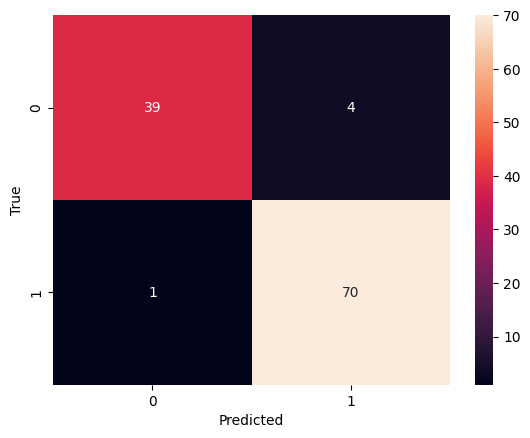

Precision: 0.9459459459459459
Recall: 0.9859154929577465
F1 Score: 0.9655172413793104


In [18]:
y_pred = grid_search_svc.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Precision, Recall, F1 Score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

In [19]:
# Using only the first two features for visualization
X_2D = X[:, :2]
X_train_2D, X_test_2D, y_train_2D, y_test_2D = train_test_split(X_2D, y, test_size=0.2, random_state=42)


In [20]:
best_lr_params = grid_search_lr.best_params_
best_lr_params["solver"] = "liblinear"  # or "saga"
best_lr = LogisticRegression(**best_lr_params).fit(X_train_2D, y_train_2D)
best_dt = DecisionTreeClassifier(**grid_search_dt.best_params_).fit(X_train_2D, y_train_2D)
best_svc = SVC(**grid_search_svc.best_params_).fit(X_train_2D, y_train_2D)


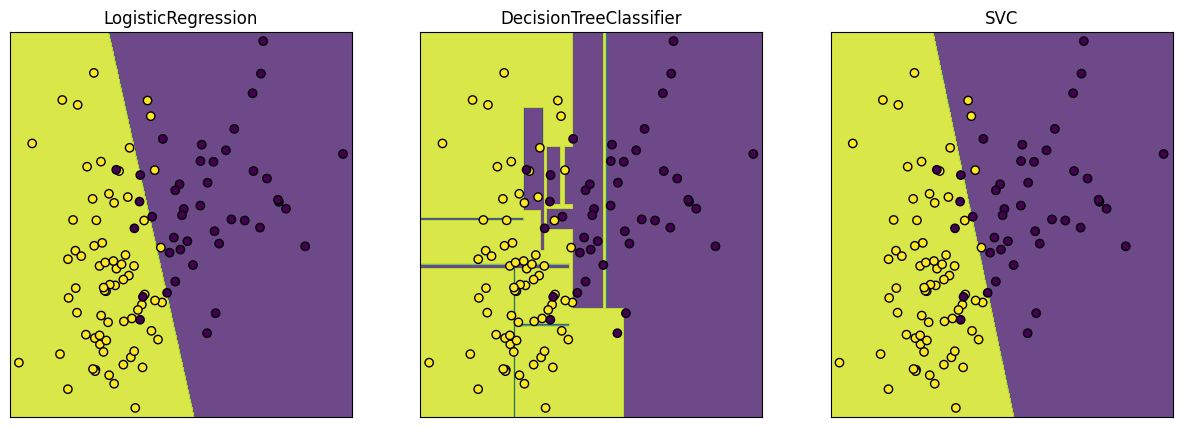

In [21]:
import numpy as np

def plot_decision_boundary(model, X, y, ax):
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.8)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    ax.set_xlim(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5)
    ax.set_ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(type(model).__name__)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_decision_boundary(best_lr, X_test_2D, y_test_2D, axes[0])
plot_decision_boundary(best_dt, X_test_2D, y_test_2D, axes[1])
plot_decision_boundary(best_svc, X_test_2D, y_test_2D, axes[2])
plt.show()
